<a href="https://colab.research.google.com/github/GANESHPARDESHI07/Assignment1/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
We aim to build a neural network from scratch to predict whether automation is cost-effective based on labor and industry features.

Target:
1 → Automation beneficial
0 → Human labor better

In [3]:
from google.colab import files
uploaded = files.upload()

Saving labor_substitution.csv to labor_substitution.csv


In [5]:
import pandas as pd

df = pd.read_csv("labor_substitution.csv")

In [6]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())

Shape: (1200, 12)

Columns:
 Index(['Role_ID', 'Industry', 'Human_Labor_Cost_hr', 'Tokens_per_Human_Hour',
       'Inference_Cost_2026', 'Agent_Labor_Equivalent_Cost',
       'Substitution_Elasticity', 'AI_Augmentation_Factor',
       'Automation_Risk_Index', 'Hardware_CapEx_Sensitivity',
       'Regulatory_Moat', 'Substitution_Year_Est'],
      dtype='object')

First 5 rows:
    Role_ID Industry  Human_Labor_Cost_hr  Tokens_per_Human_Hour  \
0  FIN-001  Finance                  114                 231710   
1  FIN-002  Finance                   97                 199855   
2  FIN-003  Finance                   58                  83259   
3  FIN-004  Finance                   73                 165341   
4  FIN-005  Finance                  100                 187993   

   Inference_Cost_2026  Agent_Labor_Equivalent_Cost  Substitution_Elasticity  \
0               0.5570                       0.1291                     0.84   
1               0.1045                       0.0209      

In [63]:
feature_names = df.columns

In [64]:
X = df.values

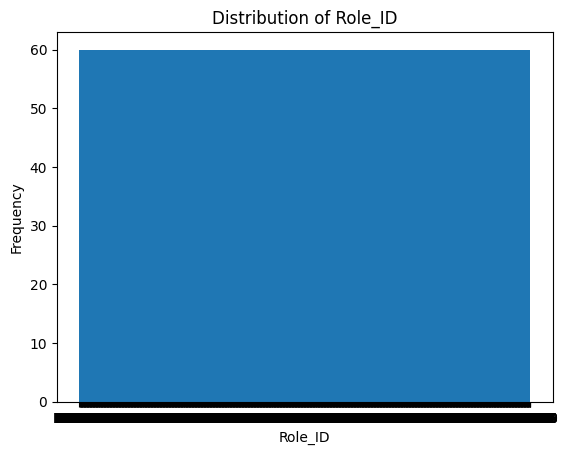

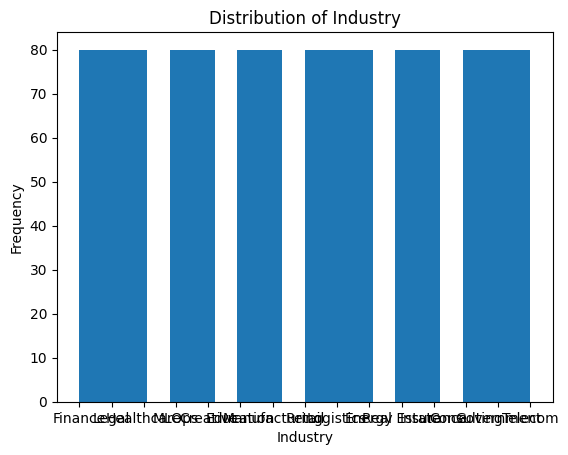

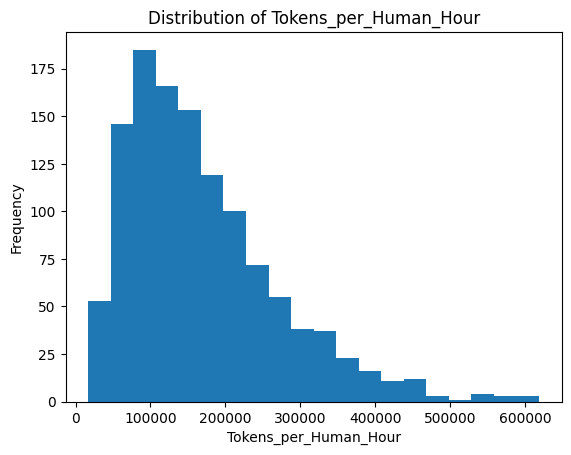

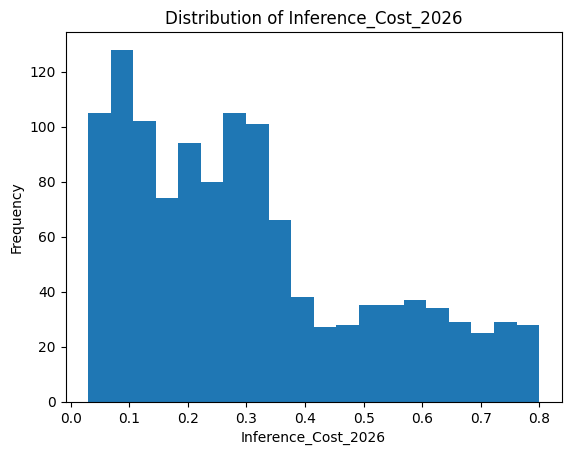

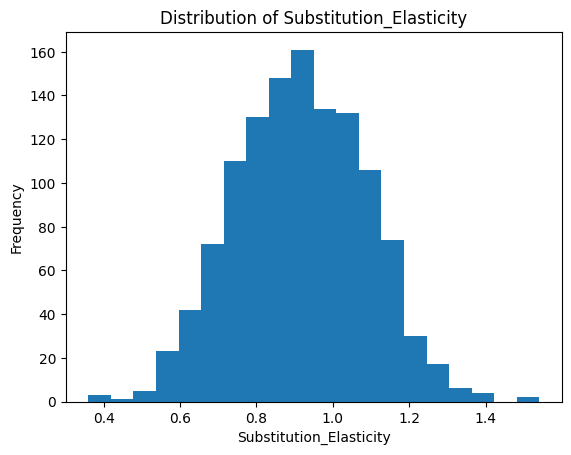

In [65]:
import matplotlib.pyplot as plt

for i in range(min(5, len(feature_names))):
    plt.hist(X[:, i], bins=20)
    plt.title(f"Distribution of {feature_names[i]}")
    plt.xlabel(feature_names[i])
    plt.ylabel("Frequency")
    plt.show()

In [7]:
print("\nData Info:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())


Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Role_ID                      1200 non-null   object 
 1   Industry                     1200 non-null   object 
 2   Human_Labor_Cost_hr          1200 non-null   int64  
 3   Tokens_per_Human_Hour        1200 non-null   int64  
 4   Inference_Cost_2026          1200 non-null   float64
 5   Agent_Labor_Equivalent_Cost  1200 non-null   float64
 6   Substitution_Elasticity      1200 non-null   float64
 7   AI_Augmentation_Factor       1200 non-null   float64
 8   Automation_Risk_Index        1200 non-null   int64  
 9   Hardware_CapEx_Sensitivity   1200 non-null   float64
 10  Regulatory_Moat              1200 non-null   object 
 11  Substitution_Year_Est        1200 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 112.6+ KB

Mis

There is no missing values and dataset is checked

In [8]:
# Create cost ratio
df['cost_ratio'] = df['Human_Labor_Cost_hr'] / df['Agent_Labor_Equivalent_Cost']

# Create target (binary classification)
df['target'] = (df['cost_ratio'] > 1).astype(int)

print(df[['cost_ratio', 'target']].head())

    cost_ratio  target
0   883.036406       1
1  4641.148325       1
2  1652.421652       1
3  2205.438066       1
4  1175.088132       1


In [9]:
df = df.drop(['cost_ratio',
              'Human_Labor_Cost_hr',
              'Agent_Labor_Equivalent_Cost'], axis=1)

In [16]:
y = df['target'].values.reshape(-1,1)
X = df.drop('target', axis=1)

In [17]:
X = pd.get_dummies(X)
X = X.values

In [19]:
X = X.astype(float)

mean = X.mean(axis=0)
std = X.std(axis=0)

X = (X - mean) / (std + 1e-8)

**Train-Test Split**

In [20]:
# Shuffle data
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

# Split
split = int(0.8 * X.shape[0])

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape, y_train.shape)

(960, 1225) (960, 1)


**Initialize** **Weights**

In [43]:
input_size = X_train.shape[1]
hidden_size = 10
output_size = 1

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

**Activation Function**

In [44]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

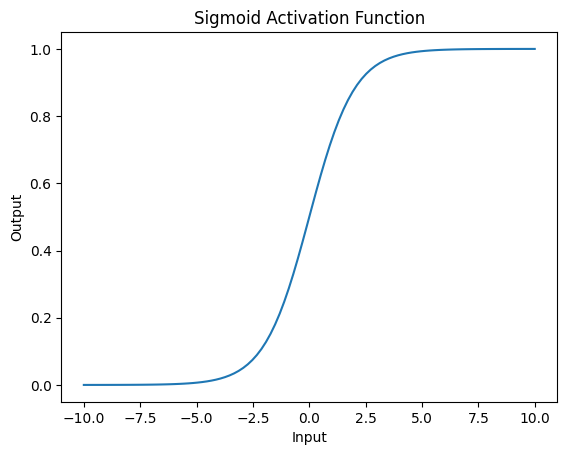

In [45]:
x = np.linspace(-10, 10, 100)

sig = 1 / (1 + np.exp(-x))

plt.plot(x, sig)
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()

**Neural Network Architecture **

In [46]:
print("Neural Network Architecture:")
print(f"Input Layer: {input_size} neurons")
print(f"Hidden Layer: {hidden_size} neurons")
print(f"Output Layer: {output_size} neuron")

Neural Network Architecture:
Input Layer: 1225 neurons
Hidden Layer: 10 neurons
Output Layer: 1 neuron


**Initial Weights**

In [47]:
print("\nInitial Weights:")
print("W1:\n", W1)
print("b1:\n", b1)
print("W2:\n", W2)
print("b2:\n", b2)


Initial Weights:
W1:
 [[ 0.04967142 -0.01382643  0.06476885 ...  0.07674347 -0.04694744
   0.054256  ]
 [-0.04634177 -0.04657298  0.02419623 ...  0.03142473 -0.09080241
  -0.14123037]
 [ 0.14656488 -0.02257763  0.00675282 ...  0.0375698  -0.06006387
  -0.02916937]
 ...
 [ 0.05582321 -0.01726264  0.09431933 ... -0.00921658  0.09669174
  -0.07230731]
 [ 0.03095556  0.05433396 -0.08605239 ... -0.07631064  0.10049303
  -0.0392801 ]
 [-0.10866362  0.01028142  0.06490934 ... -0.06630922  0.04528743
  -0.0266213 ]]
b1:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
W2:
 [[ 0.09259661]
 [-0.12971643]
 [ 0.23683345]
 [ 0.08560481]
 [-0.1684004 ]
 [-0.07090289]
 [ 0.0816081 ]
 [ 0.11763441]
 [-0.12722376]
 [ 0.07130259]]
b2:
 [[0.]]


In [48]:
# Separate classes
class0 = df[df['target'] == 0]
class1 = df[df['target'] == 1]

# Balance dataset
min_size = min(len(class0), len(class1))

class0 = class0.sample(min_size)
class1 = class1.sample(min_size)

df_balanced = pd.concat([class0, class1])

**Training Loop**

In [56]:
for epoch in range(epochs):

    # FORWARD
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # LOSS
    loss = -np.mean(y_train*np.log(A2+1e-8) + (1-y_train)*np.log(1-A2+1e-8))
    losses.append(loss)

    # BACKPROP
    dZ2 = A2 - y_train
    dW2 = np.dot(A1.T, dZ2) / X_train.shape[0]
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)

    dW1 = np.dot(X_train.T, dZ1) / X_train.shape[0]
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # UPDATE
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    # PRINT EVERY 10 EPOCHS (clean output)
    if epoch % 10 == 0:
        print(f"\nEpoch {epoch}")
        print("Loss:", loss)
        print("Sample Output:", A2[:5])


Epoch 0
Loss: 0.02103908011539072
Sample Output: [[0.98013791]
 [0.97882677]
 [0.97957723]
 [0.97764888]
 [0.97762105]]

Epoch 10
Loss: 0.017521704444387408
Sample Output: [[0.98343513]
 [0.98233965]
 [0.98296434]
 [0.98134978]
 [0.98132152]]

Epoch 20
Loss: 0.015008419939492519
Sample Output: [[0.9857971 ]
 [0.98485683]
 [0.98539131]
 [0.98400307]
 [0.98397517]]

Epoch 30
Loss: 0.01312371428568761
Sample Output: [[0.98757159]
 [0.9867483 ]
 [0.98721498]
 [0.98599762]
 [0.98597042]]

Epoch 40
Loss: 0.011658358139814496
Sample Output: [[0.98895317]
 [0.98822115]
 [0.98863507]
 [0.98755125]
 [0.98752489]]


Loss graphs

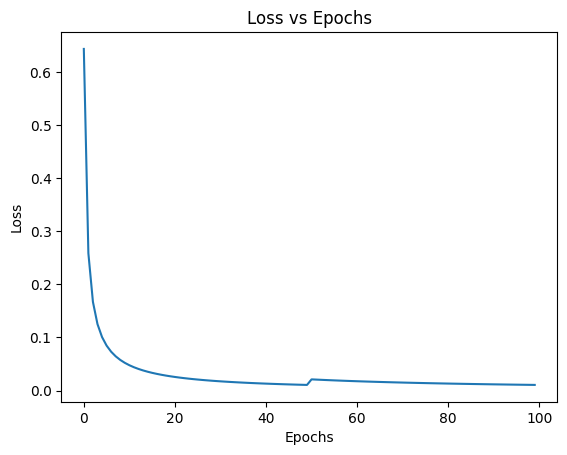

In [57]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [58]:
print("\nSample Predictions:")

for i in range(10):
    print(f"Actual: {y_test[i][0]}  Predicted: {preds[i][0]}")


Sample Predictions:
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1


**Accuracy , Precision , Recall**

In [59]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 1.0
Precision: 0.9999999999583333
Recall: 0.9999999999583333


Final Weights

In [60]:
print("\nFinal Weights:")
print("W1:\n", W1)
print("W2:\n", W2)


Final Weights:
W1:
 [[ 0.04967412 -0.01382311  0.06477351 ...  0.07674601 -0.04694468
   0.05425645]
 [-0.04634214 -0.04657033  0.02419596 ...  0.03142556 -0.09080166
  -0.14123022]
 [ 0.14656484 -0.02257928  0.00674913 ...  0.03756959 -0.0600633
  -0.02917128]
 ...
 [ 0.05582184 -0.01726199  0.09431776 ... -0.00921686  0.09669225
  -0.07230766]
 [ 0.0309577   0.05433468 -0.08604762 ... -0.07631012  0.10049357
  -0.03927955]
 [-0.10866434  0.01028006  0.06490622 ... -0.06630945  0.04528639
  -0.02662149]]
W2:
 [[ 0.09492554]
 [-0.12732986]
 [ 0.2390561 ]
 [ 0.08795765]
 [-0.16603739]
 [-0.06850498]
 [ 0.08392297]
 [ 0.1199016 ]
 [-0.12482184]
 [ 0.07355901]]


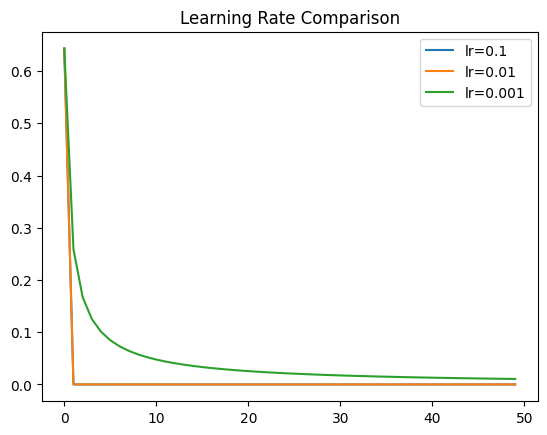

In [61]:
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    losses = []

    W1_temp = W1.copy()
    W2_temp = W2.copy()

    for epoch in range(50):
        Z1 = np.dot(X_train, W1_temp)
        A1 = sigmoid(Z1)

        Z2 = np.dot(A1, W2_temp)
        A2 = sigmoid(Z2)

        loss = -np.mean(y_train*np.log(A2+1e-8) + (1-y_train)*np.log(1-A2+1e-8))
        losses.append(loss)

        dZ2 = A2 - y_train
        dW2 = np.dot(A1.T, dZ2)

        dA1 = np.dot(dZ2, W2_temp.T)
        dZ1 = dA1 * sigmoid_derivative(A1)

        dW1 = np.dot(X_train.T, dZ1)

        W1_temp -= lr * dW1
        W2_temp -= lr * dW2

    plt.plot(losses, label=f"lr={lr}")

plt.legend()
plt.title("Learning Rate Comparison")
plt.show()

Stochastic GD

In [68]:
sgd_losses = []

W1_sgd = W1.copy()
W2_sgd = W2.copy()

for epoch in range(50):
    for i in range(X_train.shape[0]):

        xi = X_train[i:i+1]
        yi = y_train[i:i+1]

        Z1 = np.dot(xi, W1_sgd)
        A1 = sigmoid(Z1)

        Z2 = np.dot(A1, W2_sgd)
        A2 = sigmoid(Z2)

        loss = -np.mean(yi*np.log(A2+1e-8) + (1-yi)*np.log(1-A2+1e-8))
        sgd_losses.append(loss)

        dZ2 = A2 - yi
        dW2 = np.dot(A1.T, dZ2)

        dA1 = np.dot(dZ2, W2_sgd.T)
        dZ1 = dA1 * sigmoid_derivative(A1)

        dW1 = np.dot(xi.T, dZ1)

        W1_sgd -= 0.003 * dW1
        W2_sgd -= 0.003 * dW2

Mini-Batch GD

In [69]:
mini_losses = []
batch_size = 32

W1_mb = W1.copy()
W2_mb = W2.copy()

for epoch in range(50):
    for i in range(0, X_train.shape[0], batch_size):

        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        Z1 = np.dot(X_batch, W1_mb)
        A1 = sigmoid(Z1)

        Z2 = np.dot(A1, W2_mb)
        A2 = sigmoid(Z2)

        loss = -np.mean(y_batch*np.log(A2+1e-8) + (1-y_batch)*np.log(1-A2+1e-8))
        mini_losses.append(loss)

        dZ2 = A2 - y_batch
        dW2 = np.dot(A1.T, dZ2)

        dA1 = np.dot(dZ2, W2_mb.T)
        dZ1 = dA1 * sigmoid_derivative(A1)

        dW1 = np.dot(X_batch.T, dZ1)

        W1_mb -= 0.003 * dW1
        W2_mb -= 0.003 * dW2

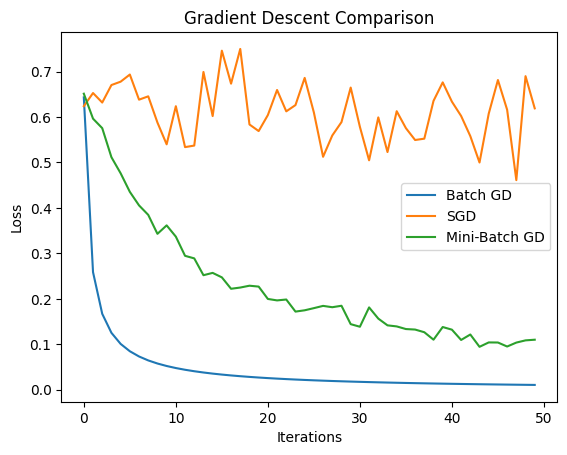

In [72]:
import matplotlib.pyplot as plt

plt.plot(losses, label="Batch GD")
plt.plot(sgd_losses[:len(losses)], label="SGD")
plt.plot(mini_losses[:len(losses)], label="Mini-Batch GD")

plt.legend()
plt.title("Gradient Descent Comparison")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [66]:
print("Final Prediction Summary:")
print("Total Test Samples:", len(y_test))
print("Predicted Automation (1):", np.sum(preds == 1))
print("Predicted Human (0):", np.sum(preds == 0))

Final Prediction Summary:
Total Test Samples: 240
Predicted Automation (1): 240
Predicted Human (0): 0


In [67]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 1.0
Precision: 0.9999999999583333
Recall: 0.9999999999583333


The hidden layer learns intermediate patterns from input features.
Each neuron in the hidden layer applies a weighted transformation followed by a sigmoid activation.
This allows the network to learn non-linear relationships in the data.